send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
X_ref = 6.555000 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\2790014320.py:107: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\2790014320.py:107: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Joined dataframe:
rows: 7669
start: 2025-12-11 15:25:02.469999
slut : 2025-12-11 15:27:32.450000
fs = 50.00250012500625 Hz
smooth_window = 100


,Mode,Delta_deg,Phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg,Key
0,common_station,-1.0,L1,1.505905,0.106341,14.116401,0.289024,69.011249,20.983492,1.898770,1.984417,common_station_-1.0deg
1,common_station,-1.0,L2,0.582398,0.110260,13.246640,0.256763,-113.218296,21.756791,1.875989,1.954564,common_station_-1.0deg
2,common_station,-1.0,L3,-0.335918,0.137426,14.032494,0.270352,-294.423341,27.117321,1.898759,2.459783,common_station_-1.0deg
3,common_station,-0.5,L1,1.645247,0.059230,10.416211,0.149016,96.506511,11.687453,1.398770,1.484417,common_station_-0.5deg
4,common_station,-0.5,L2,0.848462,0.060288,9.745412,0.131399,-60.717720,11.896192,1.375989,1.454564,common_station_-0.5deg
5,common_station,-0.5,L3,0.086836,0.075261,10.372946,0.139035,-211.004188,14.850790,1.398759,1.959783,common_station_-0.5deg
6,common_station,-0.2,L1,1.728916,0.031141,8.196310,0.066220,113.016344,6.144879,1.098770,1.184417,common_station_-0.2deg
7,common_station,-0.2,L2,1.008155,0.030473,7.644875,0.057526,-29.206543,6.013023,1.075989,1.154564,common_station_-0.2deg
8,common_station,-0.2,L3,0.340545,0.038148,8.177499,0.061659,-160.941576,7.527392,1.098759,1.659783,common_station_-0.2deg
9,common_station,-0.1,L1,1.756816,0.021923,7.456372,0.040085,118.521784,4.325883,0.998770,1.084417,common_station_-0.1deg



Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\bohus_angle_offset_sweep


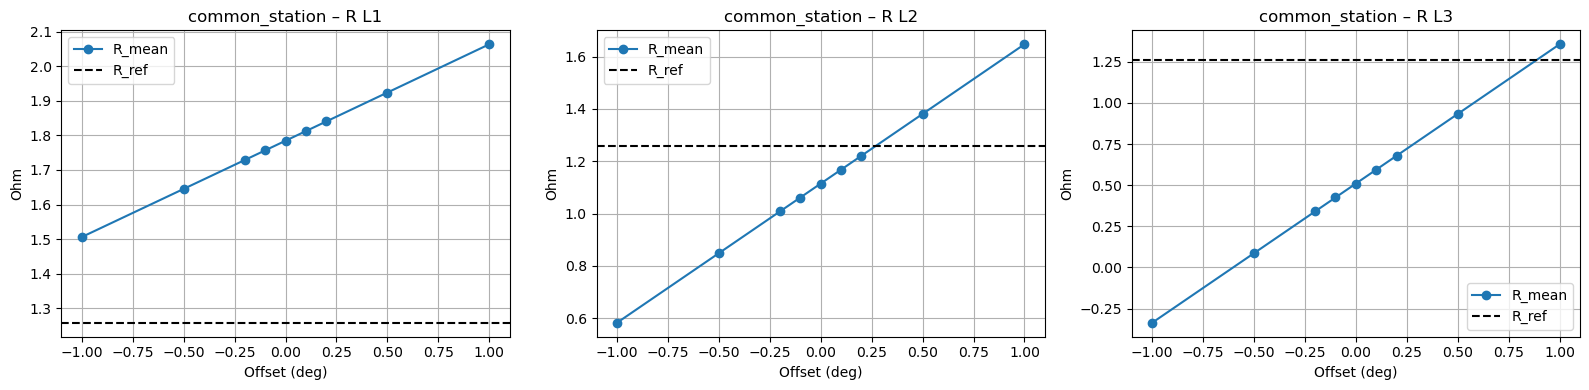

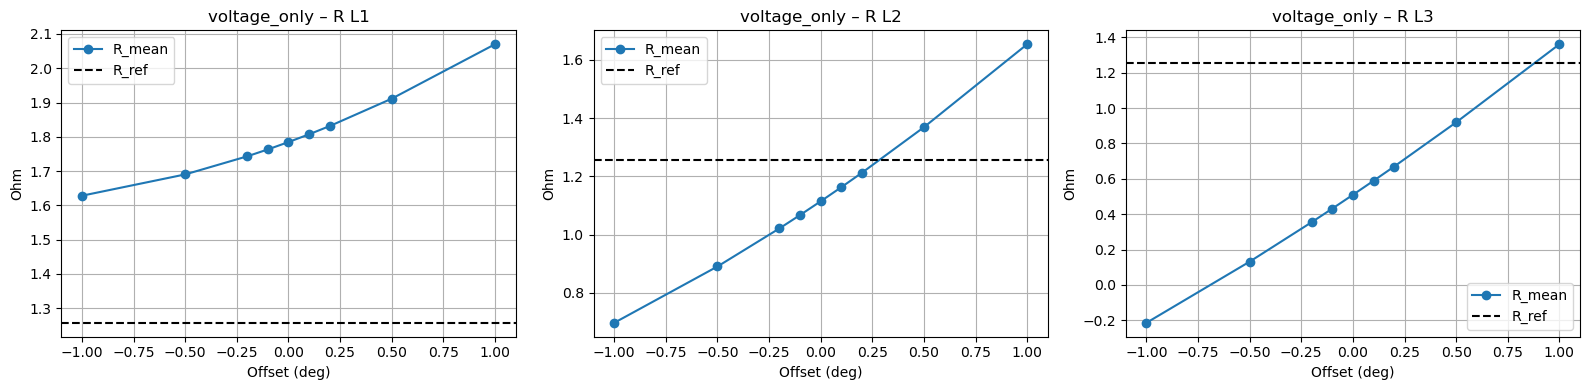

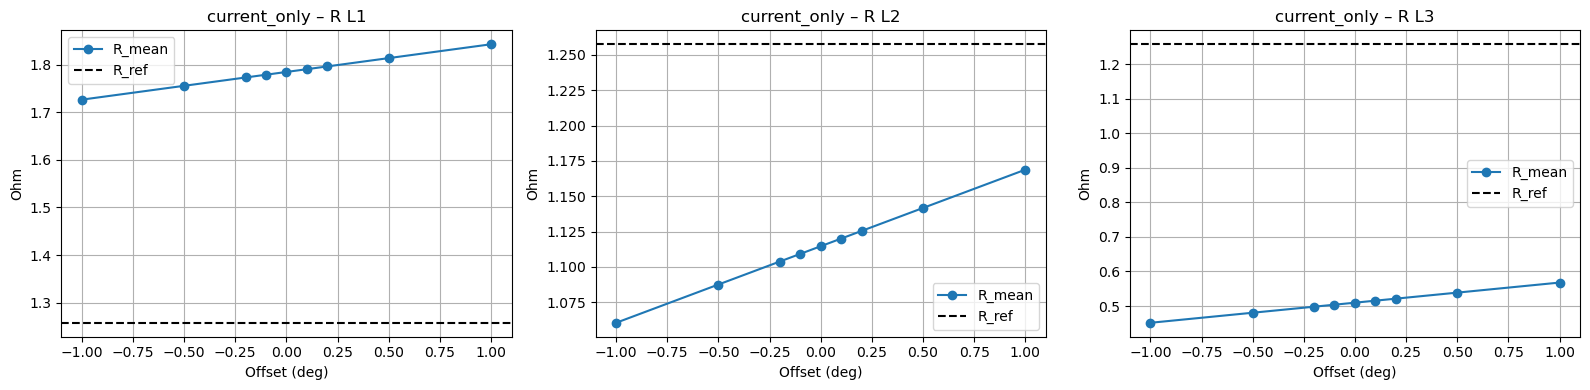

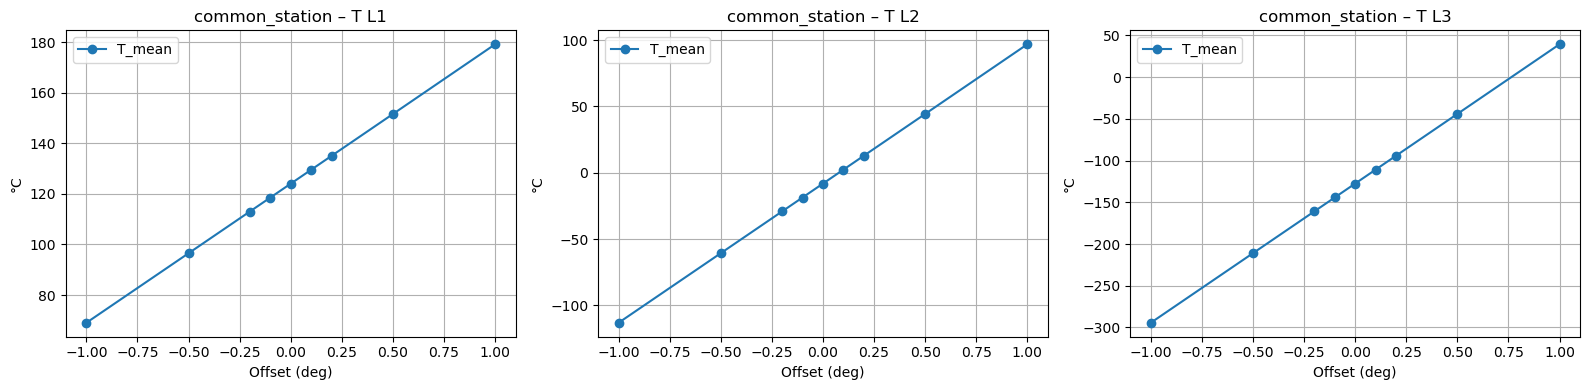

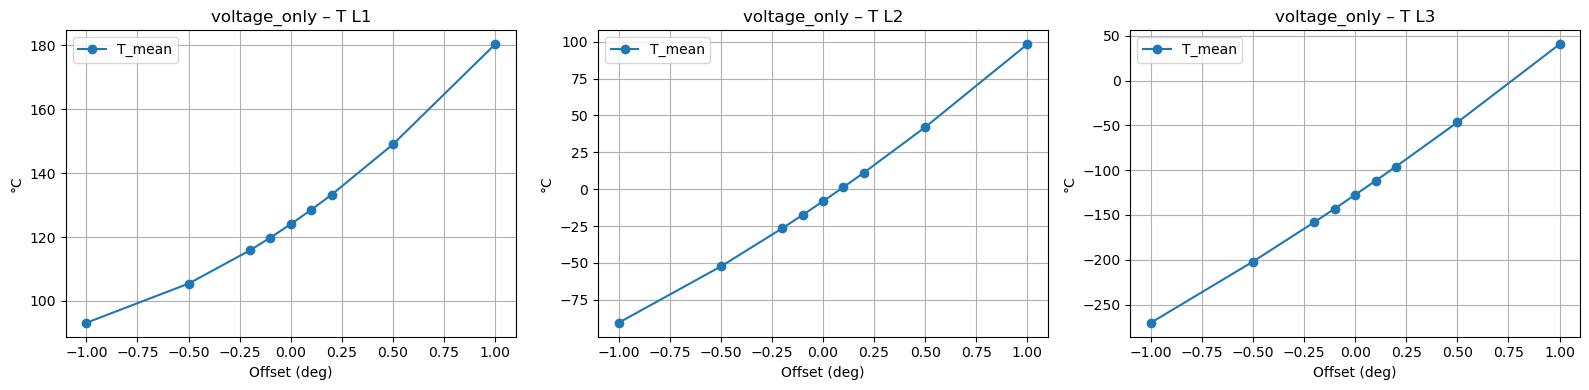

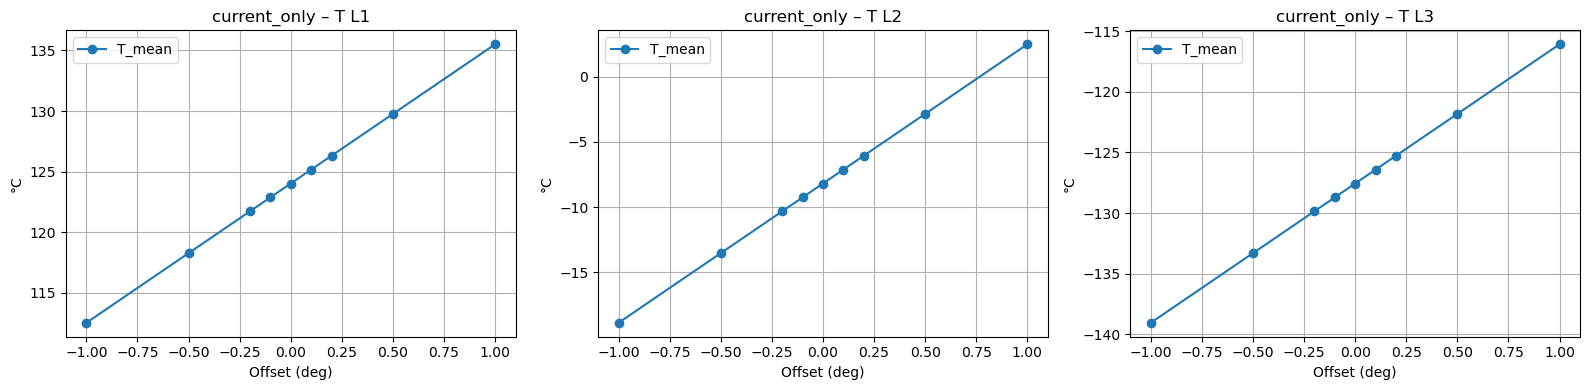

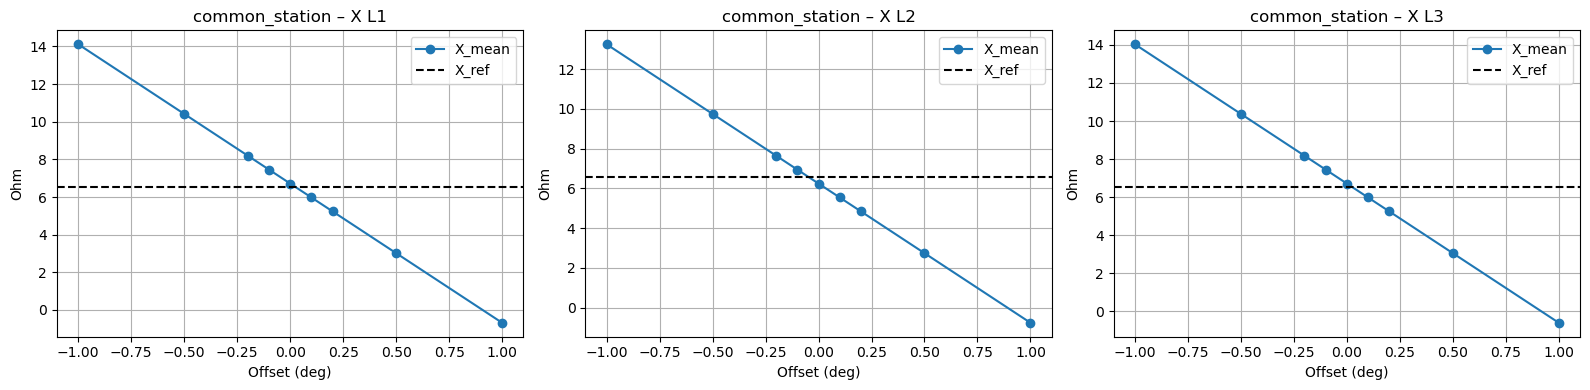

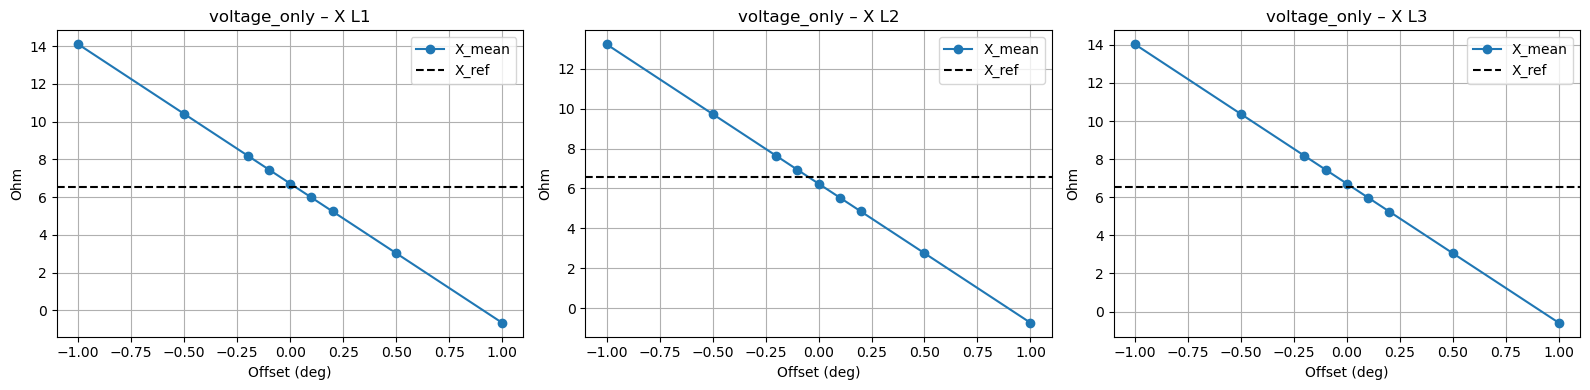

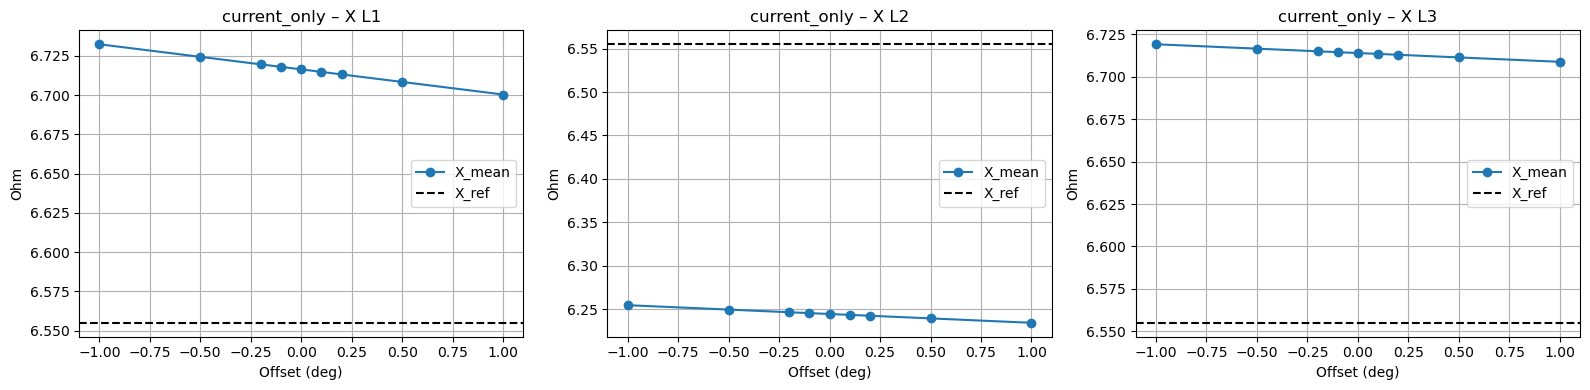

In [1]:
# ============================================================
# VINKELOFFSET-SWEEP
# Z-drop -> R -> X -> T
# Syfte:
#   visa hur känslig temperaturen är för små vinkeloffsetar
#   i mottagarstationens spännings- och strömsignaler
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
X_ref = model["X_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"X_ref = {X_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# PARAMETRAR
# ============================================================

smooth_seconds = 2.0
min_current_A = 50.0

# Sweep i grader
delta_list = [-1.0, -0.5, -0.2, -0.1, 0.0, 0.1, 0.2, 0.5, 1.0]

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_complex_mean(z, window):
    z_re = pd.Series(np.real(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    z_im = pd.Series(np.imag(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    return z_re + 1j * z_im

# ============================================================
# 1. LÄS OCH BYGG JOINED DATASET
# ============================================================

def build_joined_dataframe():
    keyS = read_key_table_safe(send_file, keyS_sheet)
    keyR = read_key_table_safe(rec_file, keyR_sheet)

    send = read_data_table_safe(send_file, dataS_sheet)
    rec  = read_data_table_safe(rec_file, dataR_sheet)

    send = send.merge(keyS, on="ID", how="inner")
    rec  = rec.merge(keyR, on="ID", how="inner")

    wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
    wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

    wideS = wideS.add_suffix("_S").sort_index()
    wideR = wideR.add_suffix("_R").sort_index()

    df_joined = wideS.join(wideR, how="inner").copy()

    required_cols = []
    for ph in ["L1", "L2", "L3"]:
        required_cols += [
            f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
            f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
        ]

    missing = [c for c in required_cols if c not in df_joined.columns]
    if missing:
        raise ValueError(f"Saknade kolumner: {missing}")

    df_joined = df_joined.dropna(subset=required_cols).copy()

    # filtrera bort orimliga vinkelvärden
    angle_cols = [c for c in df_joined.columns if "ANG" in c]
    for c in angle_cols:
        df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

    return df_joined

df_joined = build_joined_dataframe()

print("\nJoined dataframe:")
print("rows:", len(df_joined))
print("start:", df_joined.index.min())
print("slut :", df_joined.index.max())

dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt.median()
smooth_window = int(round(smooth_seconds * fs))

print("fs =", fs, "Hz")
print("smooth_window =", smooth_window)

# ============================================================
# 2. FUNKTION FÖR ETT OFFSET-SCENARIO
# ============================================================

def run_offset_scenario(df_joined, delta_deg=0.0, mode="common_station"):
    """
    mode:
      - common_station: samma delta på U_R och I_R (PMU-stationsbias)
      - voltage_only: delta bara på U_R
      - current_only: delta bara på I_R
    """
    out = pd.DataFrame(index=df_joined.index)
    summary_rows = []

    for ph in ["L1", "L2", "L3"]:
        U_mag_S = df_joined[f"U{ph}MAG_S"]
        U_ang_S = df_joined[f"U{ph}ANG_S"]
        U_mag_R = df_joined[f"U{ph}MAG_R"]
        U_ang_R = df_joined[f"U{ph}ANG_R"]

        I_mag_S = df_joined[f"I{ph}MAG_S"]
        I_ang_S = df_joined[f"I{ph}ANG_S"]
        I_mag_R = df_joined[f"I{ph}MAG_R"]
        I_ang_R = df_joined[f"I{ph}ANG_R"]

        # grundkorrigering: mottagarström definieras med 180° korrigering
        I_ang_R_corr = wrap_angle_deg(I_ang_R + 180.0)

        if mode == "common_station":
            U_ang_R_use = wrap_angle_deg(U_ang_R + delta_deg)
            I_ang_R_use = wrap_angle_deg(I_ang_R_corr + delta_deg)

        elif mode == "voltage_only":
            U_ang_R_use = wrap_angle_deg(U_ang_R + delta_deg)
            I_ang_R_use = I_ang_R_corr.copy()

        elif mode == "current_only":
            U_ang_R_use = U_ang_R.copy()
            I_ang_R_use = wrap_angle_deg(I_ang_R_corr + delta_deg)

        else:
            raise ValueError("mode måste vara common_station, voltage_only eller current_only")

        Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
        Vr = complex_from_mag_ang(U_mag_R, U_ang_R_use)

        Is = complex_from_mag_ang(I_mag_S, I_ang_S)
        Ir = complex_from_mag_ang(I_mag_R, I_ang_R_use)

        # eftersom I_ang_R_use redan inkluderar 180°-korrigeringen behövs ingen extra invertering här

        dV = Vs - Vr
        I_avg = 0.5 * (Is + Ir)

        dV_smooth = rolling_complex_mean(pd.Series(dV, index=df_joined.index), smooth_window)
        I_avg_smooth = rolling_complex_mean(pd.Series(I_avg, index=df_joined.index), smooth_window)

        I_abs = np.abs(I_avg_smooth)
        valid = I_abs > min_current_A

        Z_est = pd.Series(np.nan + 1j*np.nan, index=df_joined.index, dtype=complex)
        Z_est.loc[valid] = dV_smooth.loc[valid] / I_avg_smooth.loc[valid]

        R_est = np.real(Z_est)
        X_est = np.imag(Z_est)
        T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

        dU = wrap_angle_deg(U_ang_S - U_ang_R_use)
        dI = wrap_angle_deg(I_ang_S - I_ang_R_use)

        out[f"R_{ph}"] = R_est
        out[f"X_{ph}"] = X_est
        out[f"T_{ph}"] = T_est
        out[f"ΔU_{ph}"] = dU
        out[f"ΔI_{ph}"] = dI

        summary_rows.append({
            "Mode": mode,
            "Delta_deg": delta_deg,
            "Phase": ph,
            "R_mean_Ohm": np.nanmean(R_est),
            "R_std_Ohm": np.nanstd(R_est),
            "X_mean_Ohm": np.nanmean(X_est),
            "X_std_Ohm": np.nanstd(X_est),
            "T_mean_C": np.nanmean(T_est),
            "T_std_C": np.nanstd(T_est),
            "dU_mean_deg": circular_mean_deg(dU),
            "dI_mean_deg": circular_mean_deg(dI),
        })

    summary_df = pd.DataFrame(summary_rows)
    return out, summary_df

# ============================================================
# 3. KÖR ALLA SWEEPS
# ============================================================

all_results = []
all_outputs = {}

for mode in ["common_station", "voltage_only", "current_only"]:
    for delta in delta_list:
        key = f"{mode}_{delta:+.1f}deg"
        out_tmp, summary_tmp = run_offset_scenario(df_joined, delta_deg=delta, mode=mode)
        summary_tmp["Key"] = key
        all_results.append(summary_tmp)
        all_outputs[key] = out_tmp

summary_all = pd.concat(all_results, ignore_index=True)

display(summary_all.head(15))

# ============================================================
# 4. SPARA
# ============================================================

VERSION = "bohus_angle_offset_sweep_Z_drop_metoden"
output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

summary_all.to_excel(output_dir / "summary_angle_offset_sweep.xlsx", index=False)
summary_all.to_csv(output_dir / "summary_angle_offset_sweep.csv", index=False)

print("\nSparat till:", output_dir)

# ============================================================
# 5. PLOTTAR: R vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["R_mean_Ohm"], marker="o", label="R_mean")
        axs[i].axhline(R_ref, color="black", linestyle="--", label="R_ref")
        axs[i].set_title(f"{mode} – R {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("Ohm")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_R_vs_delta_{mode}.png", dpi=200)
    plt.show()

# ============================================================
# 6. PLOTTAR: T vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["T_mean_C"], marker="o", label="T_mean")
        axs[i].set_title(f"{mode} – T {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("°C")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_T_vs_delta_{mode}.png", dpi=200)
    plt.show()

# ============================================================
# 7. PLOTTAR: X vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["X_mean_Ohm"], marker="o", label="X_mean")
        axs[i].axhline(X_ref, color="black", linestyle="--", label="X_ref")
        axs[i].set_title(f"{mode} – X {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("Ohm")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_X_vs_delta_{mode}.png", dpi=200)
    plt.show()

=== BASELINE / ACTUAL ===


,Mode,Delta_deg,Phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg,Key
0,common_station,0.0,L1,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,0.898770,0.984417,common_station_+0.0deg
1,common_station,0.0,L2,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,0.875989,0.954564,common_station_+0.0deg
2,common_station,0.0,L3,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,0.898759,1.459783,common_station_+0.0deg


=== TEMPERATURKÄNSLIGHET MOT RESISTANS ===


,R_ref_Ohm,alpha,dT_dR_C_per_Ohm,Kommentar
0,1.257525,0.00403,197.32328,"0.01 ohm ≈ 1.97 C, 0.1 ohm ≈ 19.73 C"


=== KÄNSLIGHET NÄRA 0° ===


,Mode,Phase,dR_ddeg_Ohm_per_deg,dX_ddeg_Ohm_per_deg,dT_ddeg_C_per_deg,Allowed_delta_for_±5C_deg,Allowed_delta_for_±10C_deg
0,common_station,L1,0.279090,-7.399203,55.070870,0.090792,0.181584
1,common_station,L2,0.532481,-7.001350,105.070996,0.047587,0.095174
2,common_station,L3,0.845877,-7.317486,166.911218,0.029956,0.059912
3,voltage_only,L1,0.220884,-7.383191,43.585511,0.114717,0.229434
4,voltage_only,L2,0.478327,-6.991210,94.385031,0.052975,0.105949
5,voltage_only,L3,0.787679,-7.312312,155.427309,0.032169,0.064339
6,current_only,L1,0.058206,-0.016006,11.485326,0.435338,0.870676
7,current_only,L2,0.054154,-0.010135,10.685893,0.467907,0.935813
8,current_only,L3,0.058198,-0.005169,11.483790,0.435396,0.870793


=== RESISTANSOFFSET MOT BOHUS R_ref ===


,Phase,R_mean_actual,T_mean_actual_C,R_ref_target,Delta_R_to_ref_Ohm,T_mean_if_offset_to_ref_C
0,L1,1.784722,124.028320,1.257525,-0.527197,20.0
1,L2,1.114641,-8.194314,1.257525,0.142884,20.0
2,L3,0.509709,-127.561448,1.257525,0.747816,20.0


=== RESISTANSOFFSET MOT GEMENSAMT MEDELVÄRDE ===


,Phase,R_mean_actual,T_mean_actual_C,R_target_common,Delta_R_to_common_Ohm,T_mean_if_offset_to_common_C
0,L1,1.784722,124.028320,1.136358,-0.648365,-3.909147
1,L2,1.114641,-8.194314,1.136358,0.021716,-3.909147
2,L3,0.509709,-127.561448,1.136358,0.626648,-3.909147


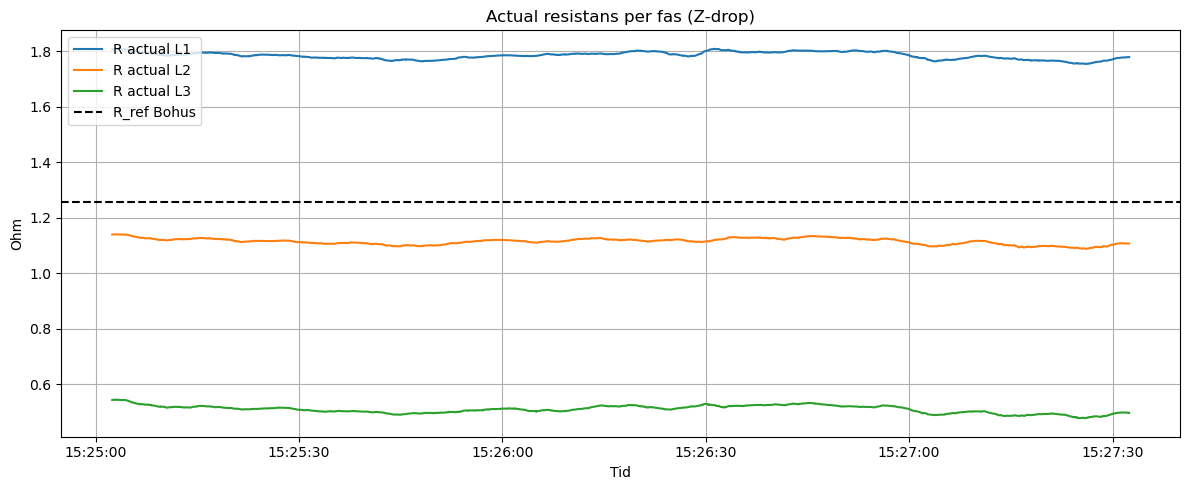

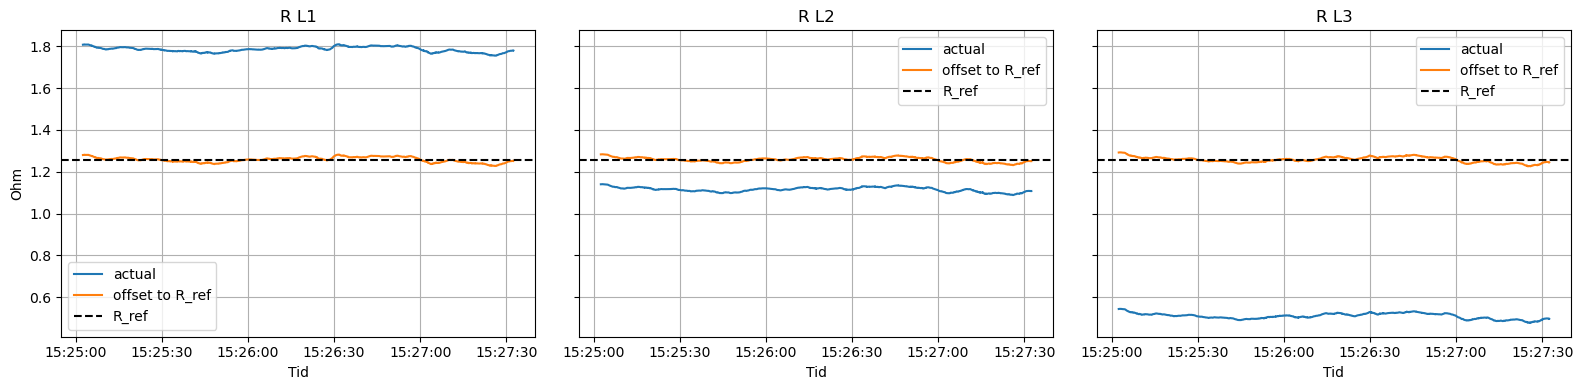

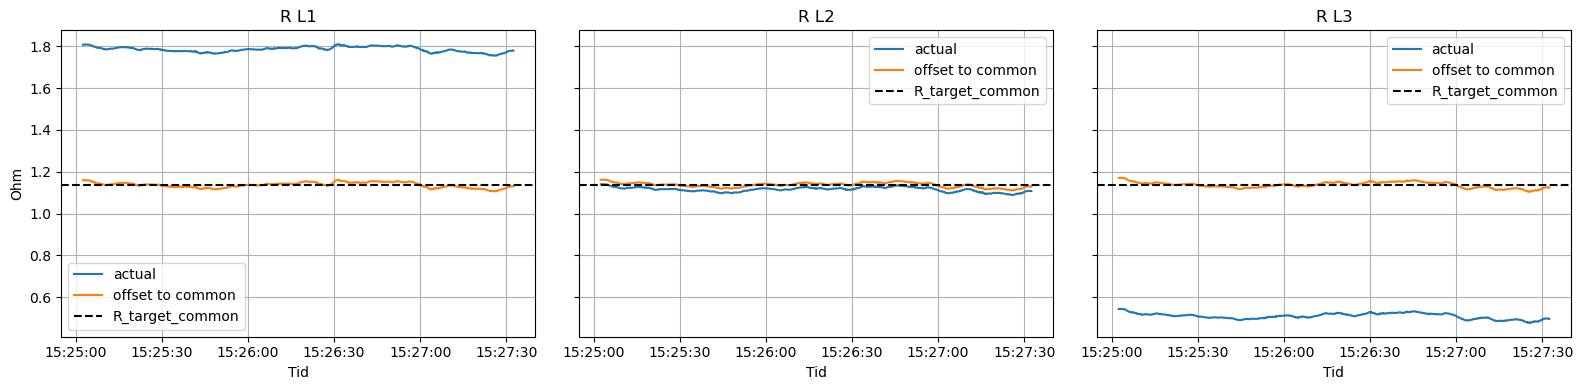

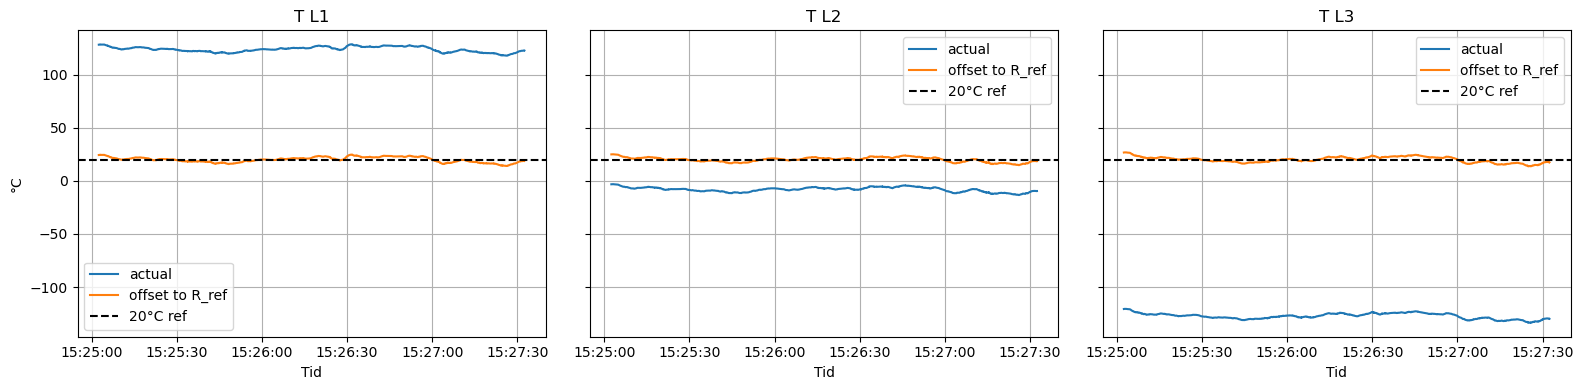

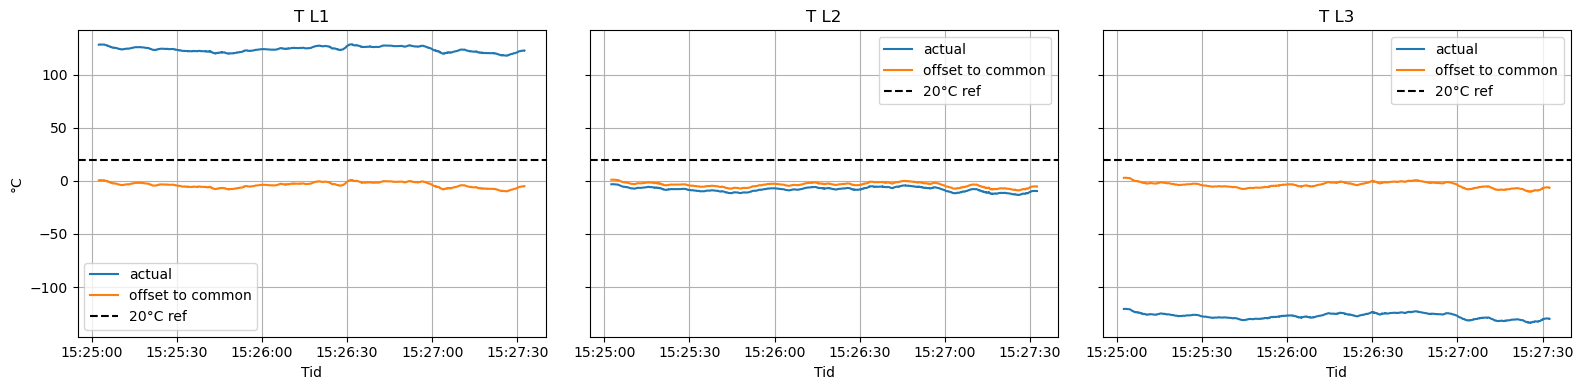

=== JÄMFÖRELSE MED / UTAN STRÖMINVERTERING ===


C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:307: RuntimeWarning: Mean of empty slice
  "R_mean_Ohm": np.nanmean(R_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:308: RuntimeWarning: Mean of empty slice
  "X_mean_Ohm": np.nanmean(X_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:309: RuntimeWarning: Mean of empty slice
  "T_mean_C": np.nanmean(T_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:307: RuntimeWarning: Mean of empty slice
  "R_mean_Ohm": np.nanmean(R_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:308: RuntimeWarning: Mean of empty slice
  "X_mean_Ohm": np.nanmean(X_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:309: RuntimeWarning: Mean of empty slice
  "T_mean_C": np.nanmean(T_est),
C:\Users\lundi\AppData\Local\Temp\ipykernel_155772\394453759.py:307: RuntimeWarning: Mean of empty slice
  "R_mean_Ohm": np.nanmean(R_est),
C:\Users\lundi\AppData\L

,Invert_receiver,Phase,R_mean_Ohm,X_mean_Ohm,T_mean_C
0,False,L1,NaN,NaN,NaN
1,False,L2,NaN,NaN,NaN
2,False,L3,NaN,NaN,NaN
3,True,L1,1.784722,6.716446,124.028320
4,True,L2,1.114641,6.244582,-8.194314
5,True,L3,0.509709,6.713966,-127.561448


Sparat extra resultat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\bohus_angle_offset_sweep\teacher_summary


In [3]:
# ============================================================
# HANDLEDAR-SAMMANFATTNING FÖR Z-DROP
# - baseline / actual
# - känslighet nära 0°
# - resistansoffset per fas
# - jämförelse med och utan inverterad mottagarström
# Kör denna EFTER din Z-drop-sweep-kod
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. HÄMTA BASELINE = ACTUAL
# Här definierar vi "minst manipulerade användbara fall":
# common_station med delta = 0°, dvs rådata + nödvändig strömriktning
# ============================================================

baseline_mode = "common_station"
baseline_delta = 0.0
baseline_key = f"{baseline_mode}_{baseline_delta:+.1f}deg"

if baseline_key not in all_outputs:
    raise ValueError(f"Hittar inte baseline-key: {baseline_key}")

out_base = all_outputs[baseline_key].copy()

baseline_df = summary_all[
    (summary_all["Mode"] == baseline_mode) &
    (summary_all["Delta_deg"] == baseline_delta)
].copy().sort_values("Phase").reset_index(drop=True)

print("=== BASELINE / ACTUAL ===")
display(baseline_df)

# ============================================================
# 2. VARFÖR KOPPLAR R SÅ STARKT TILL T?
# dT/dR = 1 / (alpha * R_ref)
# ============================================================

dT_dR = 1.0 / (alpha * R_ref)

sensitivity_text_df = pd.DataFrame([{
    "R_ref_Ohm": R_ref,
    "alpha": alpha,
    "dT_dR_C_per_Ohm": dT_dR,
    "Kommentar": "0.01 ohm ≈ %.2f C, 0.1 ohm ≈ %.2f C" % (0.01*dT_dR, 0.1*dT_dR)
}])

print("=== TEMPERATURKÄNSLIGHET MOT RESISTANS ===")
display(sensitivity_text_df)

# ============================================================
# 3. CENTRAL DIFFERENCE NÄRA 0° FÖR ATT FÅ KÄNSLIGHET
# Vi använder +/-0.1° om de finns i sweepen
# ============================================================

def central_slope(df, mode, ph, ycol, h=0.1):
    minus = df[(df["Mode"] == mode) & (df["Phase"] == ph) & (np.isclose(df["Delta_deg"], -h))]
    plus  = df[(df["Mode"] == mode) & (df["Phase"] == ph) & (np.isclose(df["Delta_deg"], +h))]

    if len(minus) == 0 or len(plus) == 0:
        return np.nan

    y_minus = minus.iloc[0][ycol]
    y_plus  = plus.iloc[0][ycol]

    return (y_plus - y_minus) / (2*h)

slope_rows = []
for mode in ["common_station", "voltage_only", "current_only"]:
    for ph in ["L1", "L2", "L3"]:
        dR_ddeg = central_slope(summary_all, mode, ph, "R_mean_Ohm", h=0.1)
        dX_ddeg = central_slope(summary_all, mode, ph, "X_mean_Ohm", h=0.1)
        dT_ddeg = central_slope(summary_all, mode, ph, "T_mean_C", h=0.1)

        tol_5 = np.nan if (pd.isna(dT_ddeg) or dT_ddeg == 0) else 5.0 / abs(dT_ddeg)
        tol_10 = np.nan if (pd.isna(dT_ddeg) or dT_ddeg == 0) else 10.0 / abs(dT_ddeg)

        slope_rows.append({
            "Mode": mode,
            "Phase": ph,
            "dR_ddeg_Ohm_per_deg": dR_ddeg,
            "dX_ddeg_Ohm_per_deg": dX_ddeg,
            "dT_ddeg_C_per_deg": dT_ddeg,
            "Allowed_delta_for_±5C_deg": tol_5,
            "Allowed_delta_for_±10C_deg": tol_10,
        })

slope_df = pd.DataFrame(slope_rows)

print("=== KÄNSLIGHET NÄRA 0° ===")
display(slope_df)

# ============================================================
# 4. RESISTANSOFFSET PER FAS
# A) mot Bohus R_ref
# B) mot gemensamt medelvärde
# ============================================================

offset_to_ref_rows = []
offset_to_common_rows = []

R_target_common = baseline_df["R_mean_Ohm"].mean()

for _, row in baseline_df.iterrows():
    ph = row["Phase"]
    R_mean = row["R_mean_Ohm"]
    T_mean = row["T_mean_C"]

    dR_ref = R_ref - R_mean
    dR_common = R_target_common - R_mean

    T_corr_ref = ((R_mean + dR_ref) / R_ref - 1.0) / alpha + T_ref
    T_corr_common = ((R_mean + dR_common) / R_ref - 1.0) / alpha + T_ref

    offset_to_ref_rows.append({
        "Phase": ph,
        "R_mean_actual": R_mean,
        "T_mean_actual_C": T_mean,
        "R_ref_target": R_ref,
        "Delta_R_to_ref_Ohm": dR_ref,
        "T_mean_if_offset_to_ref_C": T_corr_ref,
    })

    offset_to_common_rows.append({
        "Phase": ph,
        "R_mean_actual": R_mean,
        "T_mean_actual_C": T_mean,
        "R_target_common": R_target_common,
        "Delta_R_to_common_Ohm": dR_common,
        "T_mean_if_offset_to_common_C": T_corr_common,
    })

offset_to_ref_df = pd.DataFrame(offset_to_ref_rows)
offset_to_common_df = pd.DataFrame(offset_to_common_rows)

print("=== RESISTANSOFFSET MOT BOHUS R_ref ===")
display(offset_to_ref_df)

print("=== RESISTANSOFFSET MOT GEMENSAMT MEDELVÄRDE ===")
display(offset_to_common_df)

# ============================================================
# 5. SKAPA TIDSSERIER MED OFFSET-KORRIGERAD R OCH T
# ============================================================

out_refcorr = out_base.copy()
out_commoncorr = out_base.copy()

for _, row in offset_to_ref_df.iterrows():
    ph = row["Phase"]
    dR = row["Delta_R_to_ref_Ohm"]

    out_refcorr[f"R_corr_ref_{ph}"] = out_base[f"R_{ph}"] + dR
    out_refcorr[f"T_corr_ref_{ph}"] = ((out_refcorr[f"R_corr_ref_{ph}"] / R_ref) - 1.0) / alpha + T_ref

for _, row in offset_to_common_df.iterrows():
    ph = row["Phase"]
    dR = row["Delta_R_to_common_Ohm"]

    out_commoncorr[f"R_corr_common_{ph}"] = out_base[f"R_{ph}"] + dR
    out_commoncorr[f"T_corr_common_{ph}"] = ((out_commoncorr[f"R_corr_common_{ph}"] / R_ref) - 1.0) / alpha + T_ref

# ============================================================
# 6. PLOTTAR: ACTUAL RESISTANSER
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out_base.index, out_base[f"R_{ph}"], label=f"R actual {ph}")
ax.axhline(R_ref, color="black", linestyle="--", label="R_ref Bohus")
ax.set_title("Actual resistans per fas (Z-drop)")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. PLOTTAR: ACTUAL vs OFFSET MOT R_ref
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out_base.index, out_base[f"R_{ph}"], label="actual")
    axs[i].plot(out_refcorr.index, out_refcorr[f"R_corr_ref_{ph}"], label="offset to R_ref")
    axs[i].axhline(R_ref, color="black", linestyle="--", label="R_ref")
    axs[i].set_title(f"R {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Ohm")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8. PLOTTAR: ACTUAL vs OFFSET MOT GEMENSAMT MEDEL
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out_base.index, out_base[f"R_{ph}"], label="actual")
    axs[i].plot(out_commoncorr.index, out_commoncorr[f"R_corr_common_{ph}"], label="offset to common")
    axs[i].axhline(R_target_common, color="black", linestyle="--", label="R_target_common")
    axs[i].set_title(f"R {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Ohm")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 9. PLOTTAR: ACTUAL T vs OFFSET MOT R_ref
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out_base.index, out_base[f"T_{ph}"], label="actual")
    axs[i].plot(out_refcorr.index, out_refcorr[f"T_corr_ref_{ph}"], label="offset to R_ref")
    axs[i].axhline(T_ref, color="black", linestyle="--", label="20°C ref")
    axs[i].set_title(f"T {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("°C")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. PLOTTAR: ACTUAL T vs OFFSET MOT GEMENSAMT MEDEL
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out_base.index, out_base[f"T_{ph}"], label="actual")
    axs[i].plot(out_commoncorr.index, out_commoncorr[f"T_corr_common_{ph}"], label="offset to common")
    axs[i].axhline(T_ref, color="black", linestyle="--", label="20°C ref")
    axs[i].set_title(f"T {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("°C")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 11. JÄMFÖRELSE MED OCH UTAN STRÖMINVERTERING
# Detta visar varför 180°-korrigeringen inte är "fri manipulation"
# ============================================================

def run_baseline_invert_switch(df_joined, invert_receiver=True):
    """
    Samma Z-drop som baseline actual men med valbar strömriktning.
    Ingen extra offset. Bara test av I_R med/utan 180°.
    """
    out = pd.DataFrame(index=df_joined.index)
    summary_rows = []

    for ph in ["L1", "L2", "L3"]:
        U_mag_S = df_joined[f"U{ph}MAG_S"]
        U_ang_S = df_joined[f"U{ph}ANG_S"]
        U_mag_R = df_joined[f"U{ph}MAG_R"]
        U_ang_R = df_joined[f"U{ph}ANG_R"]

        I_mag_S = df_joined[f"I{ph}MAG_S"]
        I_ang_S = df_joined[f"I{ph}ANG_S"]
        I_mag_R = df_joined[f"I{ph}MAG_R"]
        I_ang_R = df_joined[f"I{ph}ANG_R"]

        if invert_receiver:
            I_ang_R_use = wrap_angle_deg(I_ang_R + 180.0)
        else:
            I_ang_R_use = I_ang_R.copy()

        Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
        Vr = complex_from_mag_ang(U_mag_R, U_ang_R)

        Is = complex_from_mag_ang(I_mag_S, I_ang_S)
        Ir = complex_from_mag_ang(I_mag_R, I_ang_R_use)

        dV = Vs - Vr
        I_avg = 0.5 * (Is + Ir)

        dV_smooth = rolling_complex_mean(pd.Series(dV, index=df_joined.index), smooth_window)
        I_avg_smooth = rolling_complex_mean(pd.Series(I_avg, index=df_joined.index), smooth_window)

        valid = np.abs(I_avg_smooth) > min_current_A

        Z_est = pd.Series(np.nan + 1j*np.nan, index=df_joined.index, dtype=complex)
        Z_est.loc[valid] = dV_smooth.loc[valid] / I_avg_smooth.loc[valid]

        R_est = np.real(Z_est)
        X_est = np.imag(Z_est)
        T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

        summary_rows.append({
            "Invert_receiver": invert_receiver,
            "Phase": ph,
            "R_mean_Ohm": np.nanmean(R_est),
            "X_mean_Ohm": np.nanmean(X_est),
            "T_mean_C": np.nanmean(T_est),
        })

        out[f"R_{ph}"] = R_est
        out[f"X_{ph}"] = X_est
        out[f"T_{ph}"] = T_est

    return out, pd.DataFrame(summary_rows)

out_noinvert, summary_noinvert = run_baseline_invert_switch(df_joined, invert_receiver=False)
out_invert, summary_invert = run_baseline_invert_switch(df_joined, invert_receiver=True)

invert_compare_df = pd.concat([summary_noinvert, summary_invert], ignore_index=True)

print("=== JÄMFÖRELSE MED / UTAN STRÖMINVERTERING ===")
display(invert_compare_df)

# ============================================================
# 12. SPARA EXTRA RESULTAT
# ============================================================

teacher_dir = output_dir / "teacher_summary"
teacher_dir.mkdir(parents=True, exist_ok=True)

baseline_df.to_excel(teacher_dir / "baseline_actual.xlsx", index=False)
slope_df.to_excel(teacher_dir / "sensitivity_slopes.xlsx", index=False)
offset_to_ref_df.to_excel(teacher_dir / "offset_to_Rref.xlsx", index=False)
offset_to_common_df.to_excel(teacher_dir / "offset_to_common.xlsx", index=False)
invert_compare_df.to_excel(teacher_dir / "invert_vs_noinvert.xlsx", index=False)

print("Sparat extra resultat till:", teacher_dir)